In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

font = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
}

In [2]:
# Constants
G = 6.67430e-11         # Gravitational constant in m^3 kg^-1 s^-2
G *= (100)**3 / 1000 # to cgs
Number_Density_Fraction = 1.16e-24

In [3]:
# Functions

def Virial_Radius( halo_mass, redshift):
    # Example values
    halo_mass = halo_mass * u.g  # Halo mass
    overdensity = 200  # Overdensity factor

    # Calculate critical density of the universe at given redshift
    critical_density = cosmo.critical_density(redshift)

    # Calculate the virial radius
    # M = (4/3) * pi * R_vir^3 * Delta * rho_c
    # Rearranging for R_vir:
    virial_radius = ((3 * halo_mass) / (4 * np.pi * overdensity * critical_density))**(1/3)

    return virial_radius.value

def Mass_Shells( coord, mass, center, num_bins ):
    # Calculate the distance from the center of mass
    dist = np.sqrt( np.sum( (coord - center)**2, axis=1 ) )

    # Calculate the virial radius
    max_radius = max( dist )

    # Calculate the bin edges
    bin_edges = np.linspace( 0, max_radius, num_bins + 1 )

    # Calculate the mass in each shell
    mass_in_shells, bin_edges = np.histogram( dist, bins=bin_edges, weights=mass )

    # Calculate the mass in each shell
    mass_in_shells = mass_in_shells * u.g

    # Calculate the volume of each shell
    shell_volume = (4/3) * np.pi * (bin_edges[1:]**3 - bin_edges[:-1]**3)

    # Calculate the density in each shell
    density_in_shells = mass_in_shells.value / shell_volume

    return density_in_shells, bin_edges

def Center_of_Quan( quan, mass ):
    # Calculate the center of mass
    coq = np.zeros(3)
    for i in range(3):
        coq[i] = np.sum( quan[:,i] * mass ) / np.sum( mass )

    return coq

def Potential( coord, mass ):
    # Calculate the potential energy of the system
    G = 6.67430e-11         # Gravitational constant in m^3 kg^-1 s^-2
    G = G * (100)**3 / 1000 # to cgs

    potential = 0
    for i in range(len(mass)):
        for j in range(i+1, len(mass)):
            r = np.sqrt( np.sum( (coord[i] - coord[j])**2 ) )
            potential += - G * mass[i] * mass[j] / r
    
    return potential

def Density_In_Beams( mass, density, num_bins, to_number_density=False ):

    if to_number_density:
        density_cal = density / Number_Density_Fraction
        bin_edges = np.logspace( -6, 9, num_bins + 1 )
    else:
        density_cal = density
        bin_edges = np.logspace( -30, -13, num_bins + 1 )

    # Calculate the mass in each beams
    density_in_beams, bin_edges = np.histogram( density_cal, bins=bin_edges, weights=mass )
    density_in_beams_fraction = density_in_beams / np.sum(mass)

    return density_in_beams_fraction, bin_edges

def Read_File( file ):
    # Open the file
    # file = h5py.File(file, 'r')
    
    # Read the file
    scale_factor        = file['Header'].attrs['Time']
    unit_length_cgs     = file['Header'].attrs['UnitLength_In_CGS']
    unit_mass_cgs       = file['Header'].attrs['UnitMass_In_CGS']
    unit_vel_cgs        = file['Header'].attrs['UnitVelocity_In_CGS']

    # Calculate the position and the velocity of the center of mass

    gas_coord   = file['PartType0']['Coordinates'][:]
    gas_vel     = file['PartType0']['Velocities'][:]
    gas_mass    = file['PartType0']['Masses'][:]
    gas_density = file['PartType0']['Density'][:]
    gas_temp    = file['PartType0']['Temperature'][:]

    coord   = gas_coord * scale_factor * unit_length_cgs
    vel     = gas_vel * np.sqrt(scale_factor) * unit_vel_cgs
    mass    = gas_mass * unit_mass_cgs
    density = gas_density * unit_mass_cgs / (unit_length_cgs * scale_factor)**3

    # Close the file

    return coord, mass, density, vel, gas_temp

def Speed_of_Sound( temperature, ele_abund ):
    # Constants for air
    gamma = 5/3  # Adiabatic index for idea gas
    R = 8.31  # Specific gas constant for ISM in J/mol·K
    m = 1.67e-3  # Molar mass of ISM in kg/mol
    X_H = 0.76  # Hydrogen mass fraction
    mu = 4 / (1 + 3*X_H + 4*X_H*ele_abund)  # Mean molecular weight of ISM

    # Calculate the speed of sound in the medium
    speed_of_sound = np.sqrt(gamma * R * temperature / (mu * m)) * 100 # in cm/s

    return speed_of_sound

def Mach_Number( velocities, masses, temperature, ele_abund ):
    # Calculate the average velocity
    # If you have masses and want to do a mass-weighted average:
    total_mass = np.sum(masses)
    average_velocity = np.sum(velocities.T * masses, axis=1) / total_mass

    # Calculate the velocity fluctuations
    velocity_fluctuations = velocities - average_velocity

    # If needed, calculate the magnitude of these fluctuations
    velocity_fluctuation_magnitudes = np.linalg.norm(velocity_fluctuations, axis=1)

    # Calculate the speed of sound in the medium
    speed_of_sound = Speed_of_Sound( temperature, ele_abund )

    # Calculate the Mach number for each particle
    mach_numbers = velocity_fluctuation_magnitudes / speed_of_sound

    return mach_numbers, velocity_fluctuation_magnitudes
    

In [4]:
r_1e0 = "output/res_-1/"
r_1e1 = "output/res_0/"
r_1e2 = "output/res_1/"
r_1e3 = "output/res_2/"
r_1e4 = "output/res_3/"
N_s = 51

In [5]:
# Calculate the mach number of the specific snapshots

f = h5py.File( r_1e0+"snapshot_%03d.hdf5" % N_s )

scale_factor        = f['Header'].attrs['Time']
h_factor            = f['Header'].attrs['HubbleParam']
unit_length_cgs     = f['Header'].attrs['UnitLength_In_CGS']
unit_mass_cgs       = f['Header'].attrs['UnitMass_In_CGS']
unit_vel_cgs        = f['Header'].attrs['UnitVelocity_In_CGS']
time = 1/scale_factor - 1

# Particle Type 0
gas_coord   = f['PartType0']['Coordinates'][:] 
gas_vel     = f['PartType0']['Velocities'][:]
gas_mass    = f['PartType0']['Masses'][:]
gas_density = f['PartType0']['Density'][:]
gas_potent  = f['PartType0']['Potential'][:]
gas_temp    = f['PartType0']['Temperature'][:]
gas_intern  = f['PartType0']['InternalEnergy'][:]
gas_electron= f['PartType0']['ElectronAbundance'][:]
gas_smooth  = f['PartType0']['SmoothingLength'][:]
gas_metal   = f['PartType0']['Metallicity'][:]

coord       = gas_coord * scale_factor * unit_length_cgs
mass        = gas_mass * unit_mass_cgs
velocity    = gas_vel * np.sqrt(scale_factor) * unit_vel_cgs
density     = gas_density * unit_mass_cgs / (unit_length_cgs * scale_factor)**3
potential   = gas_potent * unit_vel_cgs**2 / scale_factor
internal    = gas_intern * unit_vel_cgs**2
smoothing   = gas_smooth * scale_factor * unit_length_cgs

# Particle Type 1
dm_coord    = f['PartType1']['Coordinates'][:] * scale_factor * unit_length_cgs
dm_mass     = f['PartType1']['Masses'][:] * unit_mass_cgs

time = 1/scale_factor - 1

In [13]:
np.min(smoothing) / 3.08e18

0.0005307080958483948

In [11]:
# Calculate the range of the particles

x_range = np.array( [ min( np.min(coord[:,0]), np.min(dm_coord[:,0]) ), max( np.max(coord[:,0]), np.max(dm_coord[:,0]) ) ] )
y_range = np.array( [ min( np.min(coord[:,1]), np.min(dm_coord[:,1]) ), max( np.max(coord[:,1]), np.max(dm_coord[:,1]) ) ] )
z_range = np.array( [ min( np.min(coord[:,2]), np.min(dm_coord[:,2]) ), max( np.max(coord[:,2]), np.max(dm_coord[:,2]) ) ] )


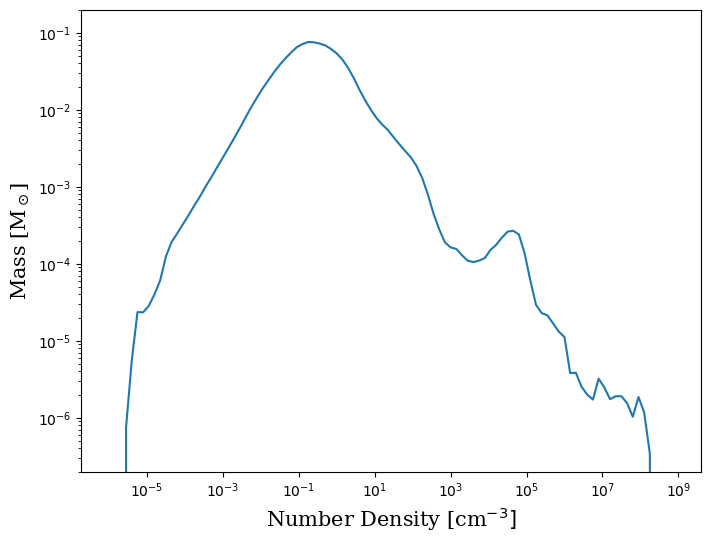

In [7]:
number_density = density / Number_Density_Fraction

# Plot the fraction of 
fraction, bin_edges = Density_In_Beams( mass, density, 100, to_number_density=True )

# Plot the figure
plt.figure( figsize=(8, 6), dpi= 100 )

plt.plot( bin_edges[:100], fraction, label='%9.1f M$_\odot$' % 0.1 )
# plt.plot( bin_edges[0:beams], fraction*np.sum(mass), label='%9.1f M$_\odot$' % 0.1 )
plt.xscale('log')
plt.yscale('log')
plt.ylim( 2e-7, 2e-1)

# plt.text( 1e-20, 3e3, 'Median Density: %.2e g cm$^{-3}$' % mean_density, fontdict=font )
# plt.text( 1e-20, 1e3, 'Std    Density: %.2e g cm$^{-3}$' % std_density, fontdict=font )

plt.xlabel('Number Density [cm$^{-3}]$', fontdict=font)
plt.ylabel('Mass [M$_\odot$]', fontdict=font)

plt.show()

Gas: 0.20
 DM: 81.63
Gas: 1.95
 DM: 81.63
Gas: 23.40
 DM: 163.26
Gas: 209.65
 DM: 2612.24
Gas: 1996.70
 DM: 20897.92


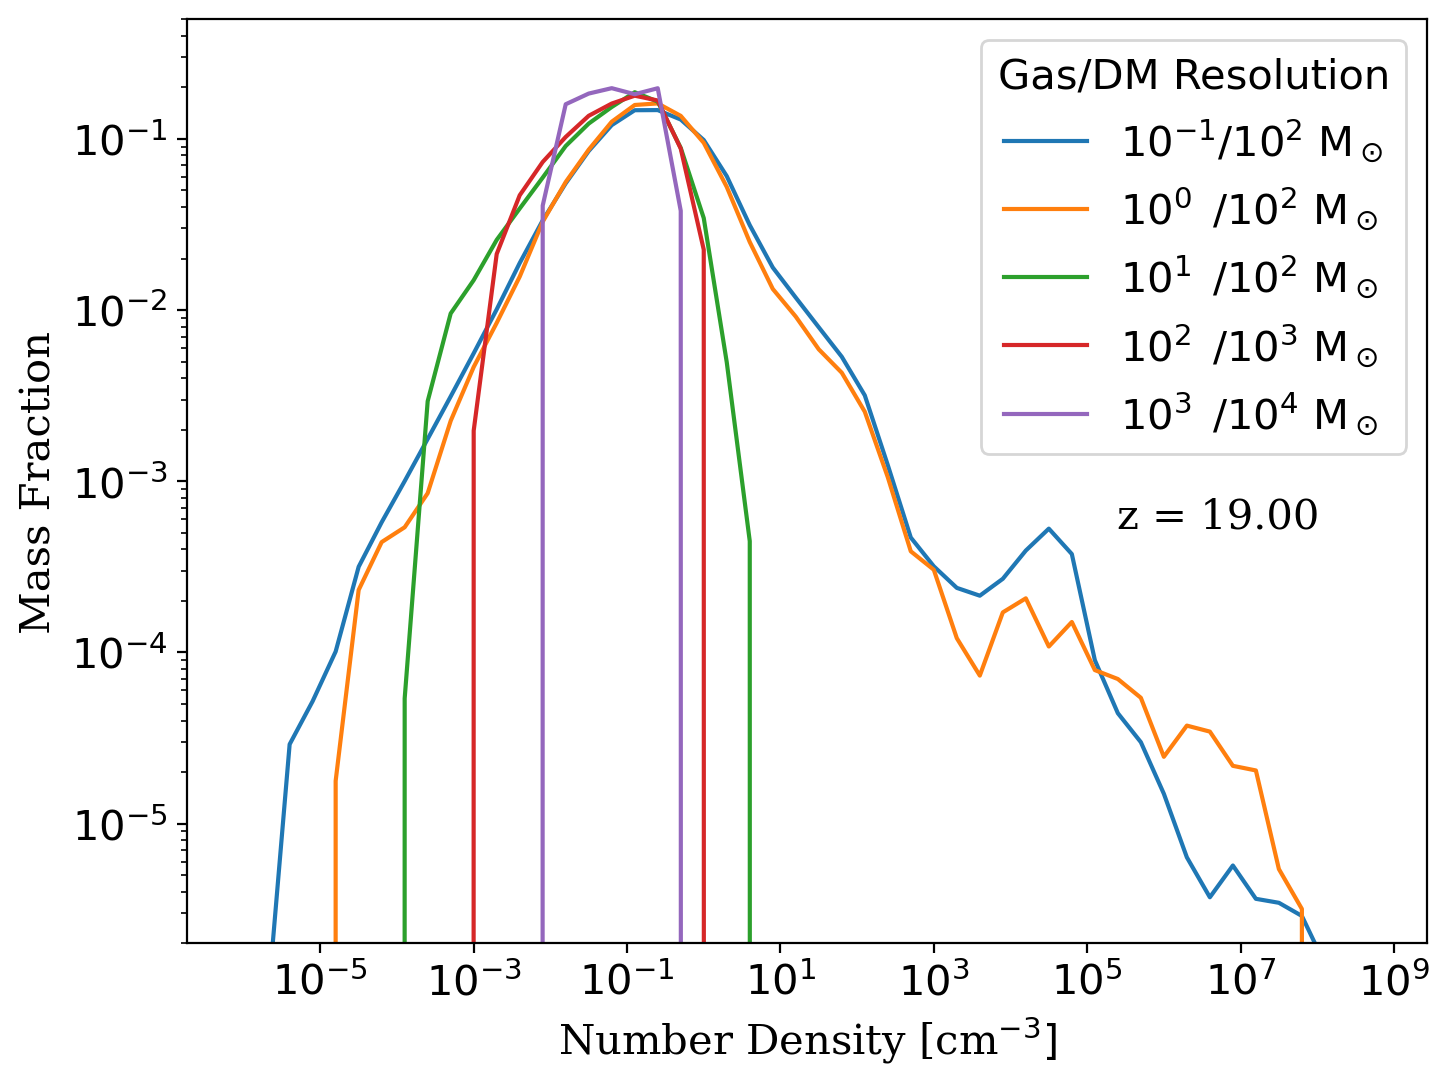

In [16]:
# Combined version

files = ["output/res_-1/", 
         "output/res_0/",
         "output/res_1/",
         "output/res_2/",
         "output/res_3/"]

plt.figure( figsize=(8, 6), dpi= 200 )

gas_resolutions = [0.1, 1, 10, 100, 1000]
dm_resolutions = [100, 100, 100, 1000, 10000]

for i, f_i in enumerate(files):
    # Calculate the mach number of the specific snapshots
    N_s = 51
    f = h5py.File( f_i + "snapshot_%03d.hdf5" % N_s )

    scale_factor        = f['Header'].attrs['Time']
    h_factor            = f['Header'].attrs['HubbleParam']
    unit_length_cgs     = f['Header'].attrs['UnitLength_In_CGS']
    unit_mass_cgs       = f['Header'].attrs['UnitMass_In_CGS']
    unit_vel_cgs        = f['Header'].attrs['UnitVelocity_In_CGS']
    time = 1/scale_factor - 1

    # Particle Type 0
    gas_coord   = f['PartType0']['Coordinates'][:] 
    gas_vel     = f['PartType0']['Velocities'][:]
    gas_mass    = f['PartType0']['Masses'][:]
    gas_density = f['PartType0']['Density'][:]
    gas_potent  = f['PartType0']['Potential'][:]
    gas_temp    = f['PartType0']['Temperature'][:]
    gas_intern  = f['PartType0']['InternalEnergy'][:]
    gas_electron= f['PartType0']['ElectronAbundance'][:]
    gas_smooth  = f['PartType0']['SmoothingLength'][:]
    gas_metal   = f['PartType0']['Metallicity'][:]

    coord       = gas_coord * scale_factor * unit_length_cgs
    mass        = gas_mass * unit_mass_cgs
    velocity    = gas_vel * np.sqrt(scale_factor) * unit_vel_cgs
    density     = gas_density * unit_mass_cgs / (unit_length_cgs * scale_factor)**3
    potential   = gas_potent * unit_vel_cgs**2 / scale_factor
    internal    = gas_intern * unit_vel_cgs**2
    smoothing   = gas_smooth * scale_factor * unit_length_cgs

    # Particle Type 1
    dm_coord    = f['PartType1']['Coordinates'][:] * scale_factor * unit_length_cgs
    dm_mass     = f['PartType1']['Masses'][:] * unit_mass_cgs

    time = 1/scale_factor - 1

    print("Gas: %.2f" % (np.mean(f['PartType0']['Masses'][:]) * unit_mass_cgs / 1.989e33))
    print(" DM: %.2f" % (np.mean(f['PartType1']['Masses'][:]) * unit_mass_cgs / 1.989e33))

    number_density = density / Number_Density_Fraction

    # Plot the fraction of 
    fraction, bin_edges = Density_In_Beams( mass, density, 50, to_number_density=True )

    # Plot the figure

    # order = 10**(i-1)
    # spacing = "    " if i < 2 else "  " if i == 2 else ""
    spacing = "\ \ " if i > 0 else ""
    plt.plot(bin_edges[:50], fraction, label=f'10$^{{{str(int(np.log10(gas_resolutions[i]))) + spacing}}}$/10$^{{{int(np.log10(dm_resolutions[i]))}}}$ M$_\odot$')

plt.xscale('log')
plt.yscale('log')
plt.ylim( 2e-6, 5e-1)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(fontsize=15, loc='upper right', title='Gas/DM Resolution', title_fontsize=15)
plt.text( 0.75, 0.45, 'z = 19.00', transform=plt.gca().transAxes, fontdict=font )

plt.xlabel('Number Density [cm$^{-3}]$', fontdict=font)
plt.ylabel('Mass Fraction', fontdict=font)

plt.show()

In [7]:
from scipy.spatial import KDTree

def fof_grouping(positions, linking_length):
    """
    Friends-of-Friends (FOF) algorithm to group particles.
    
    Parameters:
    positions : np.ndarray
        Nx3 array of particle positions.
    masses : np.ndarray
        N array of particle masses.
    linking_length : float
        The linking length threshold for grouping particles.
    
    Returns:
    list
        A list of groups where each group is a list of particle indices.
    """
    N = len(positions)
    tree = KDTree(positions)
    visited = np.zeros(N, dtype=bool)
    groups = []
    
    for i in range(N):
        if visited[i]:
            continue
        
        group = []
        queue = [i]
        while queue:
            idx = queue.pop()
            if visited[idx]:
                continue
            visited[idx] = True
            group.append(idx)
            
            neighbors = tree.query_ball_point(positions[idx], linking_length)
            # Use a fixed number of nearest neighbors instead
            # distances, neighbors = tree.query(positions[idx], k)
            queue.extend(n for n in neighbors if not visited[n])
        
        groups.append(group)
    
    return groups

In [8]:
font = {'family': 'serif',
        'weight': 'normal',
        'size': 15,
}

files = ["output/res_-1/", 
         "output/res_0/",
         "output/res_1/",
         "output/res_2/"]
        #  "output/res_3/"]

gas_resolutions = [0.1, 1, 10, 100, 1000]
dm_resolutions = [100, 100, 100, 1000, 10000]

n_bins = 5
mass_sets = []
labels = []

for i, f_i in enumerate(files):
    # Calculate the mach number of the specific snapshots
        N_s = 51
        f = h5py.File( f_i + "snapshot_%03d.hdf5" % N_s )

        scale_factor        = f['Header'].attrs['Time']
        h_factor            = f['Header'].attrs['HubbleParam']
        unit_length_cgs     = f['Header'].attrs['UnitLength_In_CGS']
        unit_mass_cgs       = f['Header'].attrs['UnitMass_In_CGS']
        unit_vel_cgs        = f['Header'].attrs['UnitVelocity_In_CGS']
        time = 1/scale_factor - 1

        # Particle Type 0
        gas_coord   = f['PartType0']['Coordinates'][:] 
        gas_vel     = f['PartType0']['Velocities'][:]
        gas_mass    = f['PartType0']['Masses'][:]
        gas_density = f['PartType0']['Density'][:]
        gas_potent  = f['PartType0']['Potential'][:]
        gas_temp    = f['PartType0']['Temperature'][:]
        gas_intern  = f['PartType0']['InternalEnergy'][:]
        gas_electron= f['PartType0']['ElectronAbundance'][:]
        gas_smooth  = f['PartType0']['SmoothingLength'][:]
        gas_metal   = f['PartType0']['Metallicity'][:]

        coord       = gas_coord * scale_factor * unit_length_cgs
        mass        = gas_mass * unit_mass_cgs
        velocity    = gas_vel * np.sqrt(scale_factor) * unit_vel_cgs
        density     = gas_density * unit_mass_cgs / (unit_length_cgs * scale_factor)**3
        potential   = gas_potent * unit_vel_cgs**2 / scale_factor
        internal    = gas_intern * unit_vel_cgs**2
        smoothing   = gas_smooth * scale_factor * unit_length_cgs

        # Particle Type 1
        dm_coord    = f['PartType1']['Coordinates'][:] * scale_factor * unit_length_cgs
        dm_mass     = f['PartType1']['Masses'][:] * unit_mass_cgs


        ratio = 10
        results = fof_grouping(dm_coord, linking_length = ratio * 3.08e18)

        # count the number of particles in each group
        group_mass = [np.log10(np.sum(dm_mass[group]) / 1.989e33) for group in results if len(group) >= 32]
        mass_sets.append(group_mass)

        spacing = "\ \ " if i > 0 else ""
        labels.append(f'10$^{{{str(int(np.log10(gas_resolutions[i]))) + spacing}}}$/10$^{{{int(np.log10(dm_resolutions[i]))}}}$ M$_\odot$')



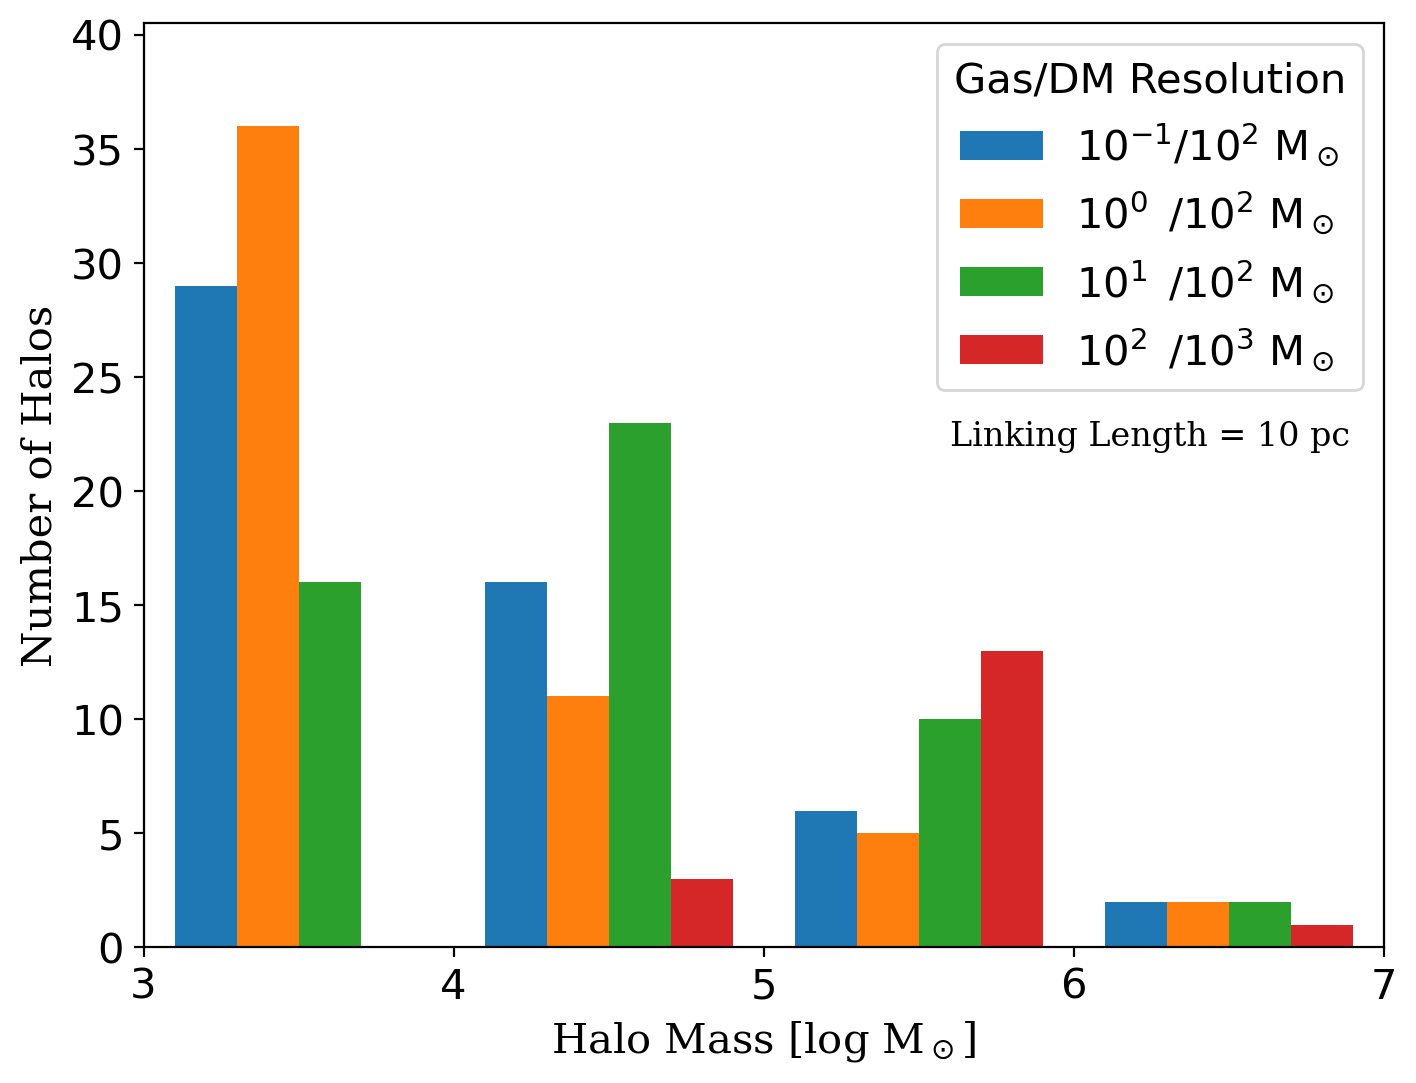

In [23]:
# HMF Prediction
x = [2e3, 2e6]        # Halo Mass [Msun]
y = [3e5, 6e2]      # dn / dlogM: number density of halos per log mass bin [Mpc^-3]
Volume =  (0.035 * scale_factor * unit_length_cgs / 3.08e21) ** 3 # Volume in Mpc^3
y_trans = np.array(y[:]) * np.array(x[:]) * Volume

plt.figure( figsize=(8, 6), dpi= 200 )
# bins = np.logspace(3, 7, 5)
bins = np.arange(3, 8, 1)
# Plot the histogram of group sizes
plt.hist( mass_sets, bins=bins, alpha=1.0, label=labels)
# plt.plot( np.log10(x), y_trans, color='black', linestyle='--', linewidth=2)

plt.xlabel('Halo Mass [log M$_\odot$]', fontdict=font)
plt.ylabel('Number of Halos', fontdict=font)

plt.xticks( np.arange(3, 8, step=1), fontsize=15 )
plt.yticks( np.arange(0, 45, step=5), fontsize=15 )

plt.xlim(3, 7)
plt.ylim(0, 40.5)

font_2 = {'family': 'serif',
        'weight': 'normal',
        'size': 12,
}
plt.text(5.6, 22.0, 'Linking Length = %d pc' % ratio, fontdict=font_2)
plt.legend(fontsize=15, loc='upper right', title='Gas/DM Resolution', title_fontsize=15)

plt.show()